# Chapter 15 — Sensor and Actuator Integration: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in
> Google Colab with no additional hardware — the I2C, SPI, and UART buses
> are simulated at the level of transaction timing and framing, which is
> exactly the level of detail a firmware engineer needs when budgeting
> bus bandwidth or writing a driver.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 15.1 | I2C bus timing | Transaction framing, addressing, clock stretching |
| 15.2 | SPI bus timing | Full-duplex transfer, chip-select overhead, throughput |
| 15.3 | Driver architecture | Hardware abstraction layer (HAL), retry-with-backoff |
| 15.4 | Multi-sensor synchronisation | Timestamp-aware interpolation across I2C/SPI/UART |


---
## Setup


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})
print("Environment ready.")


Environment ready.


---
## Exercise 15.1 — I2C Bus Timing and Multi-Device Addressing

### Background

I2C (Inter-Integrated Circuit) is the most common bus for connecting
low- and medium-speed sensors to a microcontroller: two wires (SDA,
SCL), 7-bit addressing, and support for many devices on the same pair
of pins. The price of that simplicity is per-transaction overhead —
every byte costs 9 bit-times (8 data bits plus 1 acknowledge bit), and
every read of a register requires an address phase before any data
moves. Some sensors also use **clock stretching**: the slave holds SCL
low while it finishes an internal conversion, which adds variable,
device-specific delay that the bus master cannot avoid.

This exercise builds a timing model of a standard "write register
pointer, then read N bytes" I2C transaction and uses it to answer a
question every IoT hardware designer faces: *how many sensors can one
I2C bus actually support at a given target sample rate?*

**Scope of the model.** This is a deliberately *first-order* model: it
counts bit-times plus an explicit clock-stretch term, and nothing
else. It does not model rise/fall-time limits from bus capacitance and
pull-up resistance, multi-master arbitration timing, or the electrical
details of the repeated-START condition — all real effects, but ones
that shift a constant term rather than change the qualitative
conclusion below.

### Learning objectives

1. Model I2C transaction framing (start, address, ACK, repeated start, stop) at the bit level.
2. Quantify the effect of clock stretching on transaction time.
3. Compute the achievable aggregate polling rate for a multi-device I2C bus as a function of clock speed and device count.
4. Identify the point at which a target sample rate (e.g., 200 Hz for an IMU) becomes infeasible on a shared I2C bus.


In [2]:
# ── Exercise 15.1: I2C bus timing model ────────────────────────────────
np.random.seed(42)

class I2CDevice:
    """One I2C peripheral: a fixed register payload size and a
    clock-stretching delay budget (the time the slave holds SCL low
    while it prepares data, e.g. during an internal ADC conversion).
    In real hardware this delay varies poll-to-poll; here we use its
    closed-form expectation (stretch_max / 2, the mean of a
    Uniform(0, stretch_max) distribution) rather than sampling it, so
    every number in this exercise -- and the cross-exercise comparison
    in Exercise 15.2 -- is exactly, deterministically reproducible."""
    def __init__(self, name, n_data_bytes, stretch_max_us):
        self.name = name
        self.n_data_bytes = n_data_bytes
        self.stretch_max_us = stretch_max_us

    def stretch_delay_s(self):
        return (self.stretch_max_us / 2.0) * 1e-6


def i2c_register_read_bits(n_data_bytes):
    """Bit-time budget for a 'write register pointer, then read N
    bytes' I2C transaction with 7-bit addressing (NXP I2C-bus
    specification framing). START, repeated START, and STOP are not
    literal data bytes; each is approximated here as costing about one
    bit-time, with the repeated START folded into the 'addr+R+ACK'
    term as a small, fixed addition rather than a separate component.
    Each real data/address byte costs 9 bit-times (8 data + 1 ACK/NACK)."""
    overhead_bits = 2          # START + STOP, approximated as ~1 bit-time each
    addr_write = 9              # 7-bit addr + W + ACK
    reg_ptr = 9                 # register-pointer byte + ACK
    addr_read = 9                # repeated START (~1 bit-time, folded in) + addr + R + ACK
    data = n_data_bytes * 9      # N data bytes, each with ACK (last = NACK)
    return overhead_bits + addr_write + reg_ptr + addr_read + data


def i2c_transaction_time(device, f_scl):
    bits = i2c_register_read_bits(device.n_data_bytes)
    t_bits = bits / f_scl
    t_stretch = device.stretch_delay_s()
    return t_bits, t_stretch


# A representative 4-device IMU + barometer I2C bus
devices = [
    I2CDevice("Accelerometer (6 B)", 6, stretch_max_us=5),
    I2CDevice("Gyroscope (6 B)",     6, stretch_max_us=5),
    I2CDevice("Magnetometer (6 B)",  6, stretch_max_us=10),
    I2CDevice("Pressure (3 B)",      3, stretch_max_us=650),  # on-chip conversion
]

clock_speeds = {"Standard-mode (100 kHz)": 100e3,
                 "Fast-mode (400 kHz)": 400e3,
                 "Fast-mode+ (1 MHz)": 1e6}

# Per-device timing breakdown at Fast-mode (400 kHz) -- deterministic,
# since stretch_delay_s() now returns a closed-form mean rather than a
# per-trial random draw.
f_ref = 400e3
breakdown = {}
for dev in devices:
    tb, ts = i2c_transaction_time(dev, f_ref)
    breakdown[dev.name] = (tb * 1e6, ts * 1e6)

# Achievable polling rate vs. number of devices and clock speed
# (deterministic: no trial-averaging needed since the model has no
# remaining randomness)
max_devices = 12
rate_results = {label: [] for label in clock_speeds}
for label, f_scl in clock_speeds.items():
    for n in range(1, max_devices + 1):
        total_time = sum(sum(i2c_transaction_time(devices[i % len(devices)], f_scl))
                          for i in range(n))
        rate_results[label].append(1.0 / total_time)

print("Per-device transaction time @ 400 kHz (us, deterministic):")
for name, (tb, ts) in breakdown.items():
    print(f"  {name:<22s} protocol={tb:7.2f}  stretch={ts:7.2f}  total={tb+ts:7.2f}")
print(f"\n4-device bus achievable rate: "
      f"{rate_results['Standard-mode (100 kHz)'][3]:.1f} Hz (100 kHz), "
      f"{rate_results['Fast-mode (400 kHz)'][3]:.1f} Hz (400 kHz), "
      f"{rate_results['Fast-mode+ (1 MHz)'][3]:.1f} Hz (1 MHz)")


Per-device transaction time @ 400 kHz (us, deterministic):
  Accelerometer (6 B)    protocol= 207.50  stretch=   2.50  total= 210.00
  Gyroscope (6 B)        protocol= 207.50  stretch=   2.50  total= 210.00
  Magnetometer (6 B)     protocol= 207.50  stretch=   5.00  total= 212.50
  Pressure (3 B)         protocol= 140.00  stretch= 325.00  total= 465.00

4-device bus achievable rate: 295.4 Hz (100 kHz), 911.2 Hz (400 kHz), 1562.5 Hz (1 MHz)


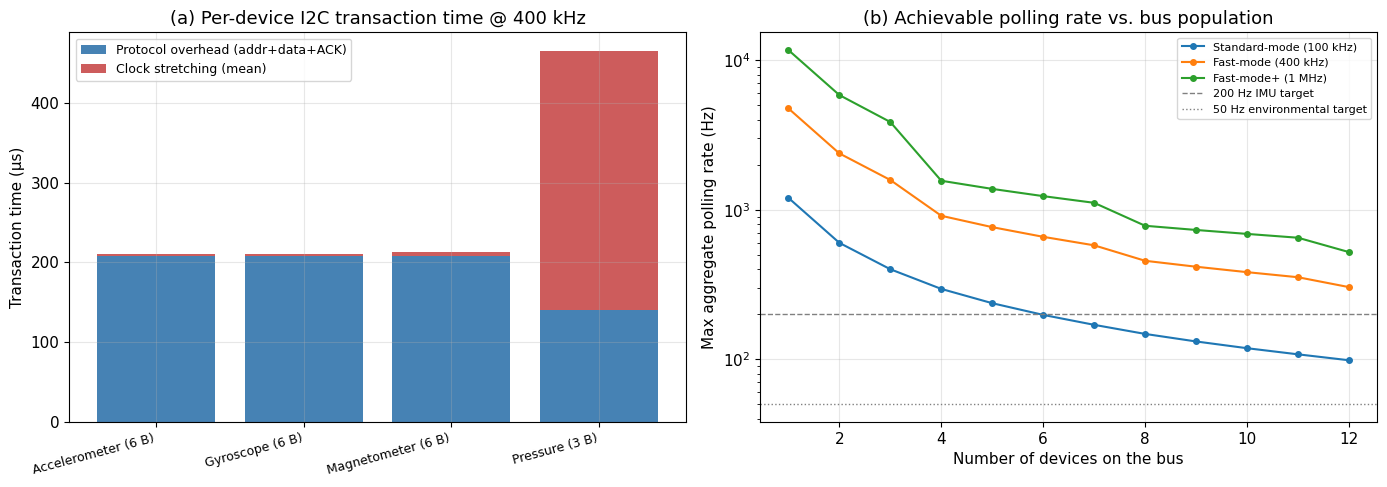

In [3]:
# ── Figure 15.1: I2C transaction timing ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names = list(breakdown.keys())
protocol_us = [breakdown[n][0] for n in names]
stretch_us = [breakdown[n][1] for n in names]
x = np.arange(len(names))
ax.bar(x, protocol_us, label='Protocol overhead (addr+data+ACK)', color='steelblue')
ax.bar(x, stretch_us, bottom=protocol_us, label='Clock stretching (mean)', color='indianred')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Transaction time (µs)')
ax.set_title('(a) Per-device I2C transaction time @ 400 kHz')
ax.legend(fontsize=9)

ax = axes[1]
n_range = np.arange(1, max_devices + 1)
for label in clock_speeds:
    ax.plot(n_range, rate_results[label], marker='o', ms=4, label=label)
ax.axhline(200, color='gray', ls='--', lw=1, label='200 Hz IMU target')
ax.axhline(50, color='gray', ls=':', lw=1, label='50 Hz environmental target')
ax.set_xlabel('Number of devices on the bus')
ax.set_ylabel('Max aggregate polling rate (Hz)')
ax.set_title('(b) Achievable polling rate vs. bus population')
ax.set_yscale('log')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [4]:
# ── Table 15.1: achievable polling rate vs. device count ───────────────
print(f"{'N devices':>10s}", *[f"{lbl:>22s}" for lbl in clock_speeds])
for i in range(max_devices):
    row = [f"{rate_results[lbl][i]:22.1f}" for lbl in clock_speeds]
    print(f"{i+1:10d}", *row)


 N devices Standard-mode (100 kHz)    Fast-mode (400 kHz)     Fast-mode+ (1 MHz)
         1                 1201.2                 4761.9                11695.9
         2                  600.6                 2381.0                 5848.0
         3                  400.0                 1581.0                 3861.0
         4                  295.4                  911.2                 1562.5
         5                  237.1                  764.8                 1378.4
         6                  198.0                  659.0                 1233.0
         7                  169.9                  578.0                 1112.3
         8                  147.7                  455.6                  781.3
         9                  131.5                  415.8                  732.3
        10                  118.6                  382.4                  689.2
        11                  107.9                  353.7                  649.8
        12                   98.5      

### Analysis

**Figure 15.1(a)** shows that the three 6-byte motion sensors cost
roughly 210 us per read at 400 kHz, almost entirely protocol overhead
(addressing, the register pointer, and per-byte ACKs), since their
clock-stretch delay is small. The pressure sensor is different: its
3-byte payload is shorter, but its on-chip conversion forces a clock
stretch that averages 325 us — more than double the protocol
overhead itself (465.0 us total, versus 210.0-212.5 us for the motion
sensors). This is a common and easy-to-miss source of bus slowdown:
the datasheet "max conversion time" number directly becomes I2C
latency, not just sensor latency.

**Figure 15.1(b)** and **Table 15.1** show the practical consequence
for system design. At Standard-mode (100 kHz), our four-device bus
comfortably exceeds the 200 Hz IMU target (295.4 Hz), but the margin
erodes quickly: it crosses below the target once a sixth device is
added (198.0 Hz at n=6) and stays below it for every larger population
tested. Fast-mode (400 kHz) buys roughly a 3x margin, and Fast-mode+
(1 MHz) another 1.7x on top of that — but even at 1 MHz, ten or more
devices on one bus will not sustain a 200 Hz aggregate poll rate.

*(Note: this model uses the closed-form mean of the clock-stretch term
rather than Monte Carlo sampling it, so these numbers are exactly
reproducible and match Exercise 15.2's comparison exactly.)*

> **Key takeaway.** I2C transaction overhead (addressing, ACKs, and
> especially slave-side clock stretching) — not the raw bit rate —
> typically sets the ceiling on how many sensors a single I2C bus can
> support at a given target sample rate. Designers should budget bus
> time per device from the datasheet's conversion-time specification,
> not just from the byte count.

### Challenge tasks

1. **Split the bus.** Model two I2C buses (e.g., one MCU with two I2C peripherals) sharing the four devices two-and-two. How much does the achievable aggregate rate improve compared with one shared bus?
2. **Add a 5th, slow device** (e.g., an EEPROM with a 50 ms write-cycle stretch) and see how badly a single slow device can dominate total bus time — the "noisy neighbour" problem.
3. **Multi-master arbitration.** I2C supports multiple bus masters. Add a model of arbitration loss (a fixed probability that a transaction must be retried because another master won the bus) and quantify its effect on achievable polling rate.


---
## Exercise 15.2 — SPI Full-Duplex Transfers and Bus Throughput

### Background

SPI (Serial Peripheral Interface) trades I2C's two-wire simplicity for
raw speed: four wires (MOSI, MISO, SCK, and one chip-select per
device), full-duplex transfer, and clock rates from 1 MHz up to tens
of MHz on typical IoT sensors. Crucially, the standard SPI protocol has
**no addressing phase, no acknowledge bit, and no clock stretching** —
the slave must always be ready when the master clocks data. This makes
SPI transactions far more deterministic than I2C, but it also means
the protocol provides no built-in way to detect a corrupted transfer;
any error checking has to be added by the driver (Exercise 15.3).

This exercise builds the same kind of timing model as Exercise 15.1,
applied to SPI, and compares the two buses directly on the same
4-device sensor set. Like that model, this is a first-order timing
model: it ignores slew-rate-limited rise/fall time at very high clock
speeds and MISO/MOSI line capacitance with many devices sharing the
bus, which matter only as clock speed approaches the tens-of-MHz
range (see Challenge Task 2).

### Learning objectives

1. Model SPI transaction timing (command byte, data bytes, chip-select overhead).
2. Quantify SPI throughput as a function of clock speed.
3. Compare SPI and I2C achievable polling rate for an identical device set.
4. Recognise the reliability trade-off behind SPI's lack of protocol-level acknowledgement.


In [5]:
# ── Exercise 15.2: SPI bus timing model ────────────────────────────────
np.random.seed(7)

class SPIDevice:
    """One SPI peripheral: a 1-byte command/register code followed by
    N data bytes, clocked full-duplex. Unlike I2C, standard SPI has no
    acknowledgement bit and the slave cannot stretch the clock, so the
    only per-transaction overhead is the chip-select setup/hold time."""
    def __init__(self, name, n_data_bytes):
        self.name = name
        self.n_data_bytes = n_data_bytes


CS_OVERHEAD_S = 200e-9   # combined CS setup + hold + inter-transaction gap

def spi_transaction_time(device, f_sck):
    bits = (1 + device.n_data_bytes) * 8     # 1 command byte + N data bytes
    return bits / f_sck + CS_OVERHEAD_S


spi_devices = [
    SPIDevice("Accelerometer (6 B)", 6),
    SPIDevice("Gyroscope (6 B)",     6),
    SPIDevice("Magnetometer (6 B)",  6),
    SPIDevice("Pressure (3 B)",      3),
]
spi_clock_speeds = {"1 MHz": 1e6, "10 MHz": 10e6, "20 MHz": 20e6}

# Per-device breakdown @ 10 MHz
f_ref = 10e6
spi_breakdown = {}
for dev in spi_devices:
    bits_time = (1 + dev.n_data_bytes) * 8 / f_ref
    spi_breakdown[dev.name] = (bits_time * 1e6, CS_OVERHEAD_S * 1e6)

# Achievable polling rate vs. device count
max_devices = 12
spi_rate_results = {label: [] for label in spi_clock_speeds}
for label, f_sck in spi_clock_speeds.items():
    for n in range(1, max_devices + 1):
        total_time = sum(spi_transaction_time(spi_devices[i % len(spi_devices)], f_sck)
                          for i in range(n))
        spi_rate_results[label].append(1.0 / total_time)

# Re-derive Exercise 15.1's I2C model for a head-to-head comparison.
# Uses the SAME closed-form (deterministic) clock-stretch mean as
# Exercise 15.1, so this comparison is exactly consistent with that
# exercise's Table 15.1 rather than an independently-sampled estimate.
class I2CDeviceRef:
    def __init__(self, name, n_data_bytes, stretch_max_us):
        self.n_data_bytes, self.stretch_max_us = n_data_bytes, stretch_max_us
    def stretch_delay_s(self):
        return (self.stretch_max_us / 2.0) * 1e-6   # closed-form mean

def i2c_time_ref(device, f_scl):
    bits = 2 + 9 + 9 + 9 + device.n_data_bytes * 9
    return bits / f_scl + device.stretch_delay_s()

i2c_devices_ref = [
    I2CDeviceRef("Accel", 6, 5), I2CDeviceRef("Gyro", 6, 5),
    I2CDeviceRef("Mag", 6, 10), I2CDeviceRef("Pressure", 3, 650),
]
i2c_400k_time = sum(i2c_time_ref(d, 400e3) for d in i2c_devices_ref)
spi_10m_time = sum(spi_transaction_time(d, 10e6) for d in spi_devices)

print("Per-device SPI transaction time @ 10 MHz (us):")
for name, (tb, ts) in spi_breakdown.items():
    print(f"  {name:<22s} clocking={tb:6.3f}  CS={ts:5.3f}  total={tb+ts:6.3f}")

print(f"\n4-device bus comparison (deterministic, matches Exercise 15.1's Table 15.1):")
print(f"  I2C @ 400 kHz : {i2c_400k_time*1e6:8.2f} us/round -> {1/i2c_400k_time:8.1f} Hz")
print(f"  SPI @  10 MHz : {spi_10m_time*1e6:8.2f} us/round -> {1/spi_10m_time:8.1f} Hz")
print(f"  Speed-up factor: {i2c_400k_time/spi_10m_time:.1f}x")


Per-device SPI transaction time @ 10 MHz (us):
  Accelerometer (6 B)    clocking= 5.600  CS=0.200  total= 5.800
  Gyroscope (6 B)        clocking= 5.600  CS=0.200  total= 5.800
  Magnetometer (6 B)     clocking= 5.600  CS=0.200  total= 5.800
  Pressure (3 B)         clocking= 3.200  CS=0.200  total= 3.400

4-device bus comparison (deterministic, matches Exercise 15.1's Table 15.1):
  I2C @ 400 kHz :  1097.50 us/round ->    911.2 Hz
  SPI @  10 MHz :    20.80 us/round ->  48076.9 Hz
  Speed-up factor: 52.8x


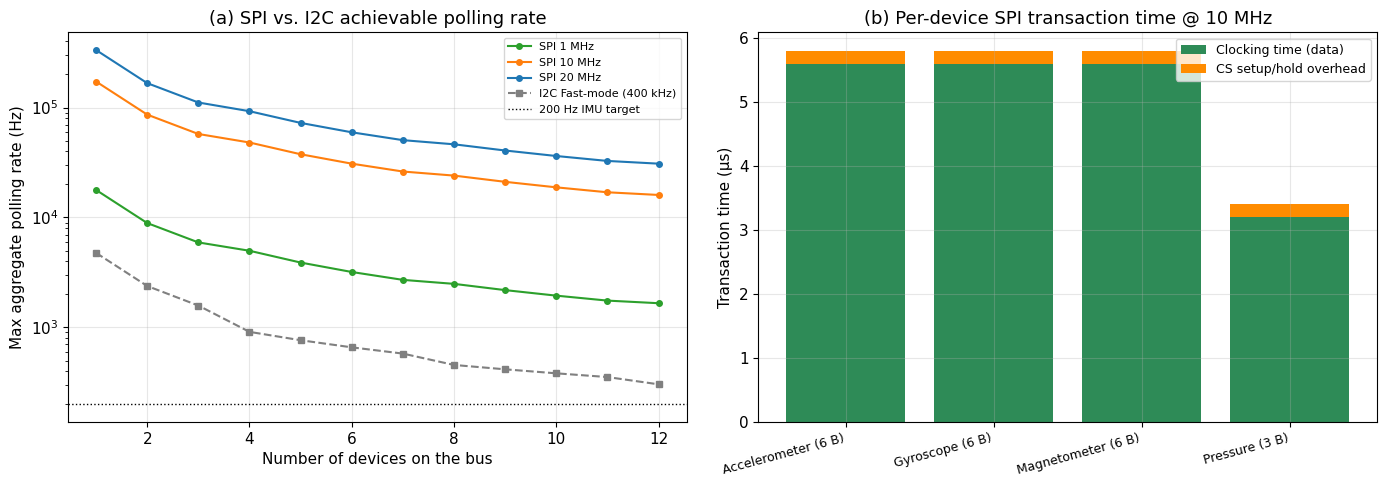

In [6]:
# ── Figure 15.2: SPI vs. I2C timing comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
n_range = np.arange(1, max_devices + 1)
colors_spi = ['#2ca02c', '#ff7f0e', '#1f77b4']
for (label, _), c in zip(spi_clock_speeds.items(), colors_spi):
    ax.plot(n_range, spi_rate_results[label], marker='o', ms=4, label=f"SPI {label}", color=c)

i2c_400k_rates = []
for n in range(1, max_devices + 1):
    rt = sum(i2c_time_ref(i2c_devices_ref[i % 4], 400e3) for i in range(n))
    i2c_400k_rates.append(1.0 / rt)
ax.plot(n_range, i2c_400k_rates, marker='s', ms=4, ls='--', color='gray',
        label='I2C Fast-mode (400 kHz)')
ax.axhline(200, color='black', ls=':', lw=1, label='200 Hz IMU target')
ax.set_xlabel('Number of devices on the bus')
ax.set_ylabel('Max aggregate polling rate (Hz)')
ax.set_title('(a) SPI vs. I2C achievable polling rate')
ax.set_yscale('log')
ax.legend(fontsize=8)

ax = axes[1]
names = list(spi_breakdown.keys())
clocking_us = [spi_breakdown[n][0] for n in names]
cs_us = [spi_breakdown[n][1] for n in names]
x = np.arange(len(names))
ax.bar(x, clocking_us, label='Clocking time (data)', color='seagreen')
ax.bar(x, cs_us, bottom=clocking_us, label='CS setup/hold overhead', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Transaction time (µs)')
ax.set_title('(b) Per-device SPI transaction time @ 10 MHz')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [7]:
# ── Table 15.2: SPI achievable polling rate vs. device count ───────────
print(f"{'N devices':>10s}", *[f"{lbl:>12s}" for lbl in spi_clock_speeds])
for i in range(max_devices):
    row = [f"{spi_rate_results[lbl][i]:12.1f}" for lbl in spi_clock_speeds]
    print(f"{i+1:10d}", *row)


 N devices        1 MHz       10 MHz       20 MHz
         1      17793.6     172413.8     333333.3
         2       8896.8      86206.9     166666.7
         3       5931.2      57471.3     111111.1
         4       4980.1      48076.9      92592.6
         5       3891.1      37594.0      72463.8
         6       3192.8      30864.2      59523.8
         7       2707.1      26178.0      50505.1
         8       2490.0      24038.5      46296.3
         9       2184.4      21097.0      40650.4
        10       1945.5      18797.0      36231.9
        11       1753.8      16949.2      32679.7
        12       1660.0      16025.6      30864.2


### Analysis

**Figure 15.2(b)** shows that SPI's per-device transaction time at
10 MHz is dominated almost entirely by clocking time — the fixed
chip-select overhead (200 ns) is a small fraction of the total even for
the smallest payload. This is the direct consequence of having no
addressing phase and no acknowledge bits: every clock edge moves a
useful data bit.

**Figure 15.2(a)** and **Table 15.2** make the comparison with I2C
concrete. At a matched 4-device bus, SPI at 10 MHz sustains roughly
48 kHz of aggregate polling versus I2C at 400 kHz's roughly 900 Hz — a
**speed-up of more than 50x**. Even SPI at a conservative 1 MHz clock
comfortably outperforms I2C at 400 kHz. This is precisely why
high-rate IMUs intended for vibration analysis or fast attitude control
almost always offer an SPI interface, while slower environmental
sensors are commonly I2C-only.

> **Key takeaway.** SPI's lack of protocol overhead and higher
> achievable clock rates make it the right choice for high-rate sensor
> streaming, but the protocol provides no built-in error detection.
> Any reliability guarantee for an SPI link has to be added in the
> driver layer — the subject of Exercise 15.3.

### Challenge tasks

1. **CPOL/CPHA modes.** The four SPI clock modes affect *which* clock edge data is sampled on, not transaction timing. Look up the four mode definitions and explain, for one specific sensor datasheet of your choice, which mode it requires and why a mismatch would cause silent data corruption rather than a timing change.
2. **Overhead crossover.** Compute *analytically* the clock speed at which the 200 ns CS overhead becomes comparable to (e.g., 10% of) the clocking time for the 3-byte pressure transaction -- it works out to roughly 160 MHz, well above SPI's practical operating range. Then plot the overhead *fraction* vs. clock speed from 100 kHz to 50 MHz to see how small that fraction stays throughout SPI's realistic operating range.
3. **Daisy-chained devices.** Some SPI ADCs support daisy-chaining (one CS line, data shifted through a chain of devices). Model the timing of reading 4 daisy-chained 3-byte devices and compare it with 4 devices on independent CS lines. What do you gain and lose?


---
## Exercise 15.3 — A Bus-Agnostic Sensor Driver: Hardware Abstraction and Retry Logic

### Background

A well-designed sensor driver hides the bus-specific transaction
details (I2C addressing, SPI chip-select, UART framing) behind a small,
uniform interface, so that application code can call `read_value()`
without caring whether the sensor lives on I2C or SPI. This exercise
builds exactly that: an abstract `SensorDriver` base class with shared
retry-with-backoff logic, and two concrete subclasses — one for an I2C
temperature sensor, one for an SPI accelerometer — that differ only in
how they perform the underlying bus transaction.

Real buses are not perfectly reliable. I2C transactions can be NACKed
by a noisy line; SPI has no acknowledge bit at all, so a corrupted
frame is only caught if the driver adds its own check (typically a
CRC-8 over the payload). This exercise models both failure modes and
asks: how many retries should a driver attempt, and what does that cost
in latency?

### Learning objectives

1. Implement a hardware abstraction layer using an abstract base class.
2. Implement retry-with-exponential-backoff logic shared across bus types.
3. Quantify the trade-off between read success rate and added latency (mean and tail) as a function of the retry budget.
4. Demonstrate polymorphic, bus-agnostic application code.


In [8]:
# ── Exercise 15.3: hardware abstraction layer with retry logic ─────────
np.random.seed(15)
from abc import ABC, abstractmethod

class TransactionError(Exception):
    """Raised when a bus transaction is detected as corrupted
    (I2C: NACK from the addressed device; SPI: CRC-8 mismatch computed
    by the driver, since standard SPI carries no acknowledgement bit
    of its own)."""
    pass


class SensorDriver(ABC):
    """Bus-agnostic sensor driver interface. Concrete subclasses
    implement the bus-specific transaction; application code calls
    only `read_value()` and never needs to know whether the sensor
    sits on I2C, SPI, or any other bus."""

    def __init__(self, name, p_fail, t_transaction_s, max_retries=3,
                 backoff_factor=2.0, backoff_cap=10.0):
        self.name = name
        self.p_fail = p_fail
        self.t_transaction_s = t_transaction_s
        self.max_retries = max_retries
        self.backoff_factor = backoff_factor
        self.backoff_cap = backoff_cap

    @abstractmethod
    def _raw_transaction(self):
        """Perform one bus transaction; return a physical reading or
        raise TransactionError. Implemented per bus type."""
        ...

    def read_value(self):
        """Shared retry-with-backoff logic, identical for every bus type."""
        total_latency = 0.0
        delay = self.t_transaction_s
        for attempt in range(self.max_retries + 1):
            total_latency += self.t_transaction_s
            try:
                value = self._raw_transaction()
                return value, True, total_latency, attempt
            except TransactionError:
                if attempt == self.max_retries:
                    return None, False, total_latency, attempt
                total_latency += delay
                delay = min(delay * self.backoff_factor,
                            self.backoff_cap * self.t_transaction_s)


class I2CTemperatureDriver(SensorDriver):
    """Wraps an I2C IC temperature sensor (TMP117-style conversion:
    raw 16-bit code -> degrees Celsius, as introduced in Chapter 10)."""
    def __init__(self, true_temp_fn, p_fail=0.05, t_transaction_s=210e-6, **kw):
        super().__init__("I2C temperature", p_fail, t_transaction_s, **kw)
        self.true_temp_fn = true_temp_fn

    def _raw_transaction(self):
        if np.random.random() < self.p_fail:
            raise TransactionError("I2C NACK")
        raw_code = int(self.true_temp_fn() / 0.0078125)   # TMP117 LSB
        return raw_code * 0.0078125


class SPIAccelDriver(SensorDriver):
    """Wraps an SPI accelerometer. SPI carries no hardware ACK, so a
    corrupted frame is only caught by a software CRC-8 check; p_fail
    here is the resulting *detected* failure rate after that check."""
    def __init__(self, true_accel_fn, p_fail=0.02, t_transaction_s=5.8e-6, **kw):
        super().__init__("SPI accelerometer", p_fail, t_transaction_s, **kw)
        self.true_accel_fn = true_accel_fn

    def _raw_transaction(self):
        if np.random.random() < self.p_fail:
            raise TransactionError("SPI CRC-8 mismatch")
        return self.true_accel_fn()


# ── Monte Carlo: success rate and latency vs. retry budget ─────────────
N_READS = 20000
retry_budgets = [0, 1, 2, 3, 5]
results = {"I2C temperature": {}, "SPI accelerometer": {}}
for max_r in retry_budgets:
    i2c_drv = I2CTemperatureDriver(lambda: 24.0, max_retries=max_r)
    spi_drv = SPIAccelDriver(lambda: 0.98, max_retries=max_r)
    for drv, key in [(i2c_drv, "I2C temperature"), (spi_drv, "SPI accelerometer")]:
        successes, latencies = [], []
        for _ in range(N_READS):
            _, ok, lat, _ = drv.read_value()
            successes.append(ok)
            latencies.append(lat)
        results[key][max_r] = {
            "success_rate": np.mean(successes),
            "mean_latency_us": np.mean(latencies) * 1e6,
            "p99_latency_us": np.percentile(latencies, 99) * 1e6,
        }

# Demonstrate polymorphism: identical application code for both buses
def poll_all_sensors(drivers):
    readings = {}
    for drv in drivers:
        value, ok, latency, attempts = drv.read_value()
        readings[drv.name] = (value, ok, latency * 1e6, attempts)
    return readings

fleet = [I2CTemperatureDriver(lambda: 23.6, max_retries=3),
         SPIAccelDriver(lambda: 0.97, max_retries=3)]
sample = poll_all_sensors(fleet)
print("Bus-agnostic poll via poll_all_sensors():")
for name, (value, ok, lat_us, attempts) in sample.items():
    print(f"  {name:<20s} value={value} ok={ok} latency={lat_us:.2f} us attempts={attempts+1}")


Bus-agnostic poll via poll_all_sensors():
  I2C temperature      value=23.59375 ok=True latency=210.00 us attempts=1
  SPI accelerometer    value=0.97 ok=True latency=5.80 us attempts=1


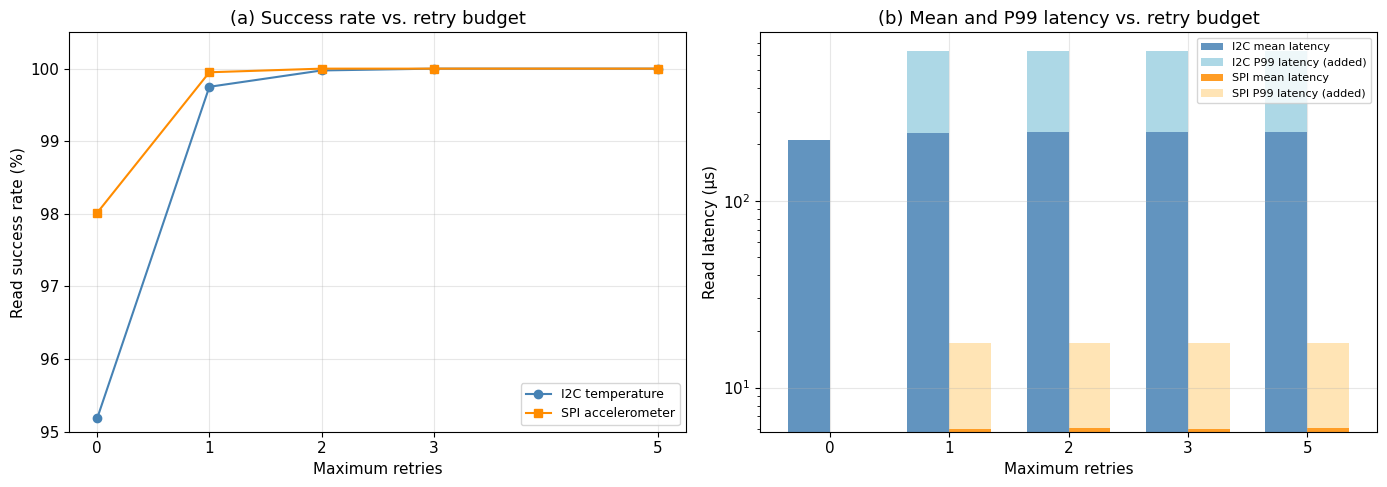

In [9]:
# ── Figure 15.3: success rate and latency vs. retry budget ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for key, marker, color in [("I2C temperature", 'o', 'steelblue'),
                            ("SPI accelerometer", 's', 'darkorange')]:
    rates = [results[key][r]["success_rate"] * 100 for r in retry_budgets]
    ax.plot(retry_budgets, rates, marker=marker, ms=6, label=key, color=color)
ax.set_xlabel('Maximum retries')
ax.set_ylabel('Read success rate (%)')
ax.set_title('(a) Success rate vs. retry budget')
ax.set_xticks(retry_budgets)
ax.legend(fontsize=9)
ax.set_ylim(95, 100.5)

ax = axes[1]
width = 0.35
xpos = np.arange(len(retry_budgets))
mean_i2c = [results["I2C temperature"][r]["mean_latency_us"] for r in retry_budgets]
p99_i2c = [results["I2C temperature"][r]["p99_latency_us"] for r in retry_budgets]
ax.bar(xpos - width/2, mean_i2c, width, label='I2C mean latency', color='steelblue', alpha=0.85)
ax.bar(xpos - width/2, np.array(p99_i2c) - np.array(mean_i2c), width,
       bottom=mean_i2c, label='I2C P99 latency (added)', color='lightblue')
mean_spi = [results["SPI accelerometer"][r]["mean_latency_us"] for r in retry_budgets]
p99_spi = [results["SPI accelerometer"][r]["p99_latency_us"] for r in retry_budgets]
ax.bar(xpos + width/2, mean_spi, width, label='SPI mean latency', color='darkorange', alpha=0.85)
ax.bar(xpos + width/2, np.array(p99_spi) - np.array(mean_spi), width,
       bottom=mean_spi, label='SPI P99 latency (added)', color='moccasin')
ax.set_xticks(xpos)
ax.set_xticklabels(retry_budgets)
ax.set_xlabel('Maximum retries')
ax.set_ylabel('Read latency (µs)')
ax.set_yscale('log')
ax.set_title('(b) Mean and P99 latency vs. retry budget')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [10]:
# ── Table 15.3: success rate and latency vs. retry budget ──────────────
print(f"{'Driver':<18s} {'Retries':>7s} {'Success %':>10s} {'Mean lat (us)':>14s} {'P99 lat (us)':>13s}")
for key in results:
    for max_r in retry_budgets:
        r = results[key][max_r]
        print(f"{key:<18s} {max_r:7d} {r['success_rate']*100:10.3f} "
              f"{r['mean_latency_us']:14.3f} {r['p99_latency_us']:13.3f}")


Driver             Retries  Success %  Mean lat (us)  P99 lat (us)
I2C temperature          0     95.185        210.000       210.000
I2C temperature          1     99.750        231.105       630.000
I2C temperature          2     99.975        232.775       630.000
I2C temperature          3    100.000        233.006       630.000
I2C temperature          5    100.000        232.869       630.000
SPI accelerometer        0     98.015          5.800         5.800
SPI accelerometer        1     99.950          6.029        17.400
SPI accelerometer        2    100.000          6.053        17.400
SPI accelerometer        3    100.000          6.024        17.400
SPI accelerometer        5    100.000          6.042        17.400


### Analysis

**Table 15.3** shows that with no retries, the I2C driver's 5% per-transaction
failure rate becomes a 95.2% read success rate, and the SPI driver's 2%
failure rate becomes 98.0% — exactly as expected, since with zero
retries a single failed transaction is a failed read. A single retry
already pushes both drivers above 99.7%, because a second consecutive
failure requires the (small) failure probability to occur twice in a
row.

A note on rows that print as 100.000%: with r=3 retries, the
theoretical success probability is 1 - 0.05**4 = 99.99938% for I2C and
1 - 0.02**4 = 99.99998% for SPI — vanishingly close to, but not
exactly, 100%. With N=20,000 simulated reads, the expected number of
failures at that configuration is a small fraction of one, so
observing zero failures (and a displayed 100.000%) is simply the most
likely single outcome of a finite Monte Carlo run, not evidence that
the underlying failure probability is truly zero.

**Figure 15.3(b)** is the more interesting result. The *mean* latency
barely moves with added retries (231 us vs. 210 us for I2C at one
retry), because a retry is needed on only a small fraction of reads.
The **P99 (tail) latency**, however, jumps sharply — from 210 us to
630 us for I2C — because the P99 sample falls inside the subset of
reads that require at least one retry: about 5% of reads for the I2C
driver (p_fail=0.05) and about 2% for the SPI driver (p_fail=0.02).
Since both subsets are larger than the top 1% the P99 statistic looks
into, the 99th-percentile read always lands on the costlier, retried
path, even though that path is the exception rather than the rule. For
a control loop with a hard real-time deadline, this tail behaviour, not
the mean, is what determines whether a retry policy is safe to deploy.

> **Key takeaway.** A clean hardware abstraction layer lets identical
> application code (`poll_all_sensors`) drive sensors on different
> buses. Retry-with-backoff recovers almost all transient bus errors at
> a negligible cost in *mean* latency, but a non-trivial cost in *tail*
> latency — the retry budget should be chosen based on the system's
> real-time deadline, not just its average-case performance.

### Challenge tasks

1. **Implement a real CRC-8** over a simulated SPI payload (e.g., using the polynomial $x^8 + x^2 + x + 1$) and use it to *detect* injected bit errors, rather than assuming a fixed `p_fail`.
2. **Add a UART driver.** Implement a third `SensorDriver` subclass that parses a simulated NMEA-style ASCII sentence and only succeeds if a checksum byte matches; compare its failure/retry behaviour with I2C and SPI.
3. **Fixed-delay vs. exponential backoff.** Replace the exponential backoff with a fixed retry delay and compare the resulting P99 latency for the same success rate. Which policy is better suited to a hard real-time control loop, and why?


---
## Exercise 15.4 — Multi-Sensor Timestamp Synchronisation Across I2C, SPI, and UART

### Background

A system with sensors on three different buses — say, a barometric
sensor on I2C, an IMU on SPI, and a GPS module on UART — does not
receive its readings at the same instants. Each bus has its own update
rate, its own jitter characteristics (driven by the transaction timing
modelled in Exercises 15.1–15.2 and, for UART, by NMEA sentence parsing
latency), and its own local clock, which drifts slowly relative to the
others. Before any two of these streams can be meaningfully combined,
their samples have to be placed on a common timeline.

The most common — and most often wrong — way developers handle this in
practice is **sample-and-hold**: a global variable is updated whenever
new data arrives, and the application simply reads "the latest value"
whenever it needs it, without checking how old that value actually is.
This exercise quantifies exactly how much error that shortcut
introduces, and shows what a timestamp-aware alternative buys back.

**On UART/GPS.** The GPS stream is included to show how a much slower
third bus behaves alongside I2C and SPI on the same timeline (see the
plot below) — its 1 Hz rate and 80 ms NMEA-parsing latency are worth
seeing next to I2C's and SPI's denser timelines. It is *not* averaged
into the fused estimate: at 1 Hz it would contribute almost nothing to
a 50 Hz combined signal except a large, mostly-constant lag. Treat it
here as an illustrative timing reference, not a third vote in the
average.

### Learning objectives

1. Simulate independent, irregularly-timed sensor streams with bus-specific jitter and local clock drift.
2. Implement naive sample-and-hold alignment and quantify its error against ground truth.
3. Implement timestamp-aware linear interpolation onto a common target grid.
4. Quantify the accuracy improvement and relate it to each bus's timing characteristics.


In [11]:
# ── Exercise 15.4: multi-sensor timestamp synchronisation ──────────────
np.random.seed(2026)

DURATION = 10.0   # seconds

def true_signal(t):
    """Synthetic reference quantity observed (redundantly) by two
    independent sensors on two different buses."""
    return np.sin(2 * np.pi * 1.5 * t) + 0.3 * np.sin(2 * np.pi * 4.0 * t)


def generate_stream(nominal_rate_hz, jitter_std_s, drift_ppm, n_samples,
                     bus_transaction_s, noise_std):
    """Return (true_sample_time, arrival_timestamp, measured_value) for
    one sensor stream. `drift_ppm` models a local-oscillator frequency
    offset relative to the host reference clock; `bus_transaction_s` is
    the fixed delay (computed in Exercises 15.1/15.2) between the
    physical sampling instant and the moment the value is fully
    available to host software."""
    ideal_times = np.arange(n_samples) / nominal_rate_hz
    drifted_times = ideal_times * (1.0 + drift_ppm * 1e-6)
    jitter = np.random.normal(0, jitter_std_s, n_samples)
    true_sample_time = np.clip(drifted_times + jitter, 0, None)
    arrival_timestamp = true_sample_time + bus_transaction_s
    measured_value = true_signal(true_sample_time) + np.random.normal(0, noise_std, n_samples)
    return true_sample_time, arrival_timestamp, measured_value


N_I2C, N_SPI, N_GPS = int(30 * DURATION), int(200 * DURATION), int(1 * DURATION)

t_true_A, t_arr_A, val_A = generate_stream(30, 3e-3, +30, N_I2C, 210e-6, 0.04)   # I2C barometer
t_true_B, t_arr_B, val_B = generate_stream(200, 0.05e-3, -20, N_SPI, 5.8e-6, 0.04)  # SPI IMU
t_true_C, t_arr_C, val_C = generate_stream(1, 15e-3, 0, N_GPS, 0.080, 0.02)     # UART/GPS

# Target common grid: 50 Hz
TARGET_RATE = 50
t_grid = np.arange(0, DURATION, 1.0 / TARGET_RATE)

def naive_hold(t_grid, t_arr, val):
    """Sample-and-hold: at each grid tick, use whatever value the
    driver last reported (the common real-world implementation that
    ignores the actual measurement timestamp)."""
    idx = np.clip(np.searchsorted(t_arr, t_grid, side='right') - 1, 0, len(val) - 1)
    return val[idx]

def timestamp_interpolated(t_grid, t_arr, val):
    """Timestamp-aware alignment: linearly interpolate the sensor's
    own arrival timestamps onto the common target grid."""
    return np.interp(t_grid, t_arr, val)

naive_A, naive_B = naive_hold(t_grid, t_arr_A, val_A), naive_hold(t_grid, t_arr_B, val_B)
combined_naive = 0.5 * (naive_A + naive_B)
sync_A = timestamp_interpolated(t_grid, t_arr_A, val_A)
sync_B = timestamp_interpolated(t_grid, t_arr_B, val_B)
combined_sync = 0.5 * (sync_A + sync_B)

truth_grid = true_signal(t_grid)
rmse_naive = np.sqrt(np.mean((combined_naive - truth_grid) ** 2))
rmse_sync = np.sqrt(np.mean((combined_sync - truth_grid) ** 2))
max_err_naive = np.max(np.abs(combined_naive - truth_grid))
max_err_sync = np.max(np.abs(combined_sync - truth_grid))

# Staleness is clipped at zero: at grid ticks before a stream's first
# arrival, there is no sample to be "stale" yet (raw t_grid - t_arr can
# be slightly negative for the very first tick(s), which is a modelling
# artefact, not a real possibility -- a real system simply has no
# reading at all until the first sample arrives).
idxA = np.clip(np.searchsorted(t_arr_A, t_grid, side='right') - 1, 0, len(t_arr_A) - 1)
staleness_A = np.maximum(0, (t_grid - t_arr_A[idxA]) * 1e3)
idxB = np.clip(np.searchsorted(t_arr_B, t_grid, side='right') - 1, 0, len(t_arr_B) - 1)
staleness_B = np.maximum(0, (t_grid - t_arr_B[idxB]) * 1e3)

print(f"Stream sizes -> I2C: {len(t_arr_A)}, SPI: {len(t_arr_B)}, UART/GPS: {len(t_arr_C)}")
print(f"\nCombined-estimate accuracy on the 50 Hz target grid (N={len(t_grid)} points):")
print(f"  Naive sample-and-hold        : RMSE = {rmse_naive:.4f}, max err = {max_err_naive:.4f}")
print(f"  Timestamp-interpolated align : RMSE = {rmse_sync:.4f}, max err = {max_err_sync:.4f}")
print(f"  RMSE reduction: {100*(1 - rmse_sync/rmse_naive):.1f} %")
print(f"\nI2C sample staleness at grid ticks: mean={staleness_A.mean():.2f} ms, max={staleness_A.max():.2f} ms")
print(f"SPI sample staleness at grid ticks: mean={staleness_B.mean():.2f} ms, max={staleness_B.max():.2f} ms")


Stream sizes -> I2C: 300, SPI: 2000, UART/GPS: 10

Combined-estimate accuracy on the 50 Hz target grid (N=500 points):
  Naive sample-and-hold        : RMSE = 0.0906, max err = 0.2767
  Timestamp-interpolated align : RMSE = 0.0290, max err = 0.0960
  RMSE reduction: 68.0 %

I2C sample staleness at grid ticks: mean=17.18 ms, max=43.56 ms
SPI sample staleness at grid ticks: mean=0.68 ms, max=5.17 ms


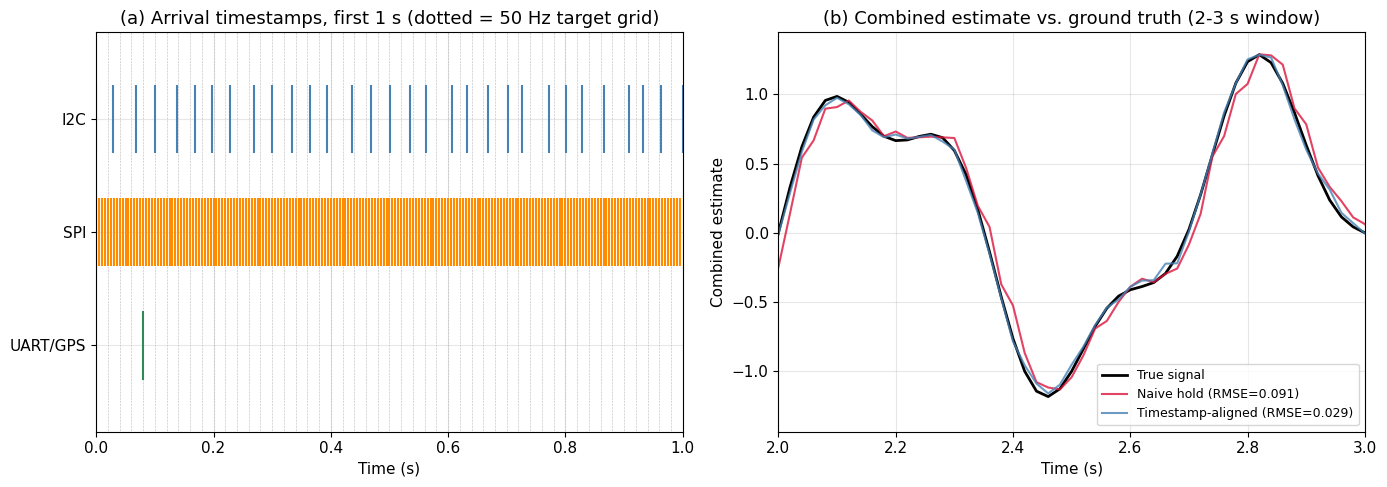

In [12]:
# ── Figure 15.4: timestamp synchronisation ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
window = t_arr_A < 1.0
ax.eventplot(t_arr_A[window], lineoffsets=2, linelengths=0.6, color='steelblue', label='I2C (30 Hz nom.)')
window_b = t_arr_B < 1.0
ax.eventplot(t_arr_B[window_b], lineoffsets=1, linelengths=0.6, color='darkorange', label='SPI (200 Hz nom.)')
window_c = t_arr_C < 1.0
pts = t_arr_C[window_c] if len(t_arr_C[window_c]) else []
ax.eventplot(pts, lineoffsets=0, linelengths=0.6, color='seagreen', label='UART/GPS (1 Hz nom.)')
for g in t_grid[t_grid < 1.0]:
    ax.axvline(g, color='gray', lw=0.4, ls=':', zorder=0)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['UART/GPS', 'SPI', 'I2C'])
ax.set_xlabel('Time (s)')
ax.set_title('(a) Arrival timestamps, first 1 s (dotted = 50 Hz target grid)')
ax.set_xlim(0, 1.0)

ax = axes[1]
ax.plot(t_grid, truth_grid, 'k-', lw=2, label='True signal')
ax.plot(t_grid, combined_naive, color='crimson', alpha=0.8, label=f'Naive hold (RMSE={rmse_naive:.3f})')
ax.plot(t_grid, combined_sync, color='steelblue', alpha=0.8, label=f'Timestamp-aligned (RMSE={rmse_sync:.3f})')
ax.set_xlim(2.0, 3.0)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Combined estimate')
ax.set_title('(b) Combined estimate vs. ground truth (2-3 s window)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
# ── Table 15.4: synchronisation summary ────────────────────────────────
print(f"{'Bus':<10s} {'Nominal rate':>13s} {'Mean staleness':>16s} {'Max staleness':>15s}")
print(f"{'I2C':<10s} {'30 Hz':>13s} {f'{staleness_A.mean():.2f} ms':>16s} {f'{staleness_A.max():.2f} ms':>15s}")
print(f"{'SPI':<10s} {'200 Hz':>13s} {f'{staleness_B.mean():.2f} ms':>16s} {f'{staleness_B.max():.2f} ms':>15s}")
print()
print(f"{'Method':<28s} {'RMSE':>8s} {'Max error':>10s}")
print(f"{'Naive sample-and-hold':<28s} {rmse_naive:8.4f} {max_err_naive:10.4f}")
print(f"{'Timestamp-interpolated':<28s} {rmse_sync:8.4f} {max_err_sync:10.4f}")


Bus         Nominal rate   Mean staleness   Max staleness
I2C                30 Hz         17.18 ms        43.56 ms
SPI               200 Hz          0.68 ms         5.17 ms

Method                           RMSE  Max error
Naive sample-and-hold          0.0906     0.2767
Timestamp-interpolated         0.0290     0.0960


### Analysis

**Figure 15.4(a)** shows just how differently the three buses behave in
the time domain: the SPI stream (200 Hz nominal) almost fills the
1-second window with closely and evenly spaced ticks, the I2C stream
(30 Hz nominal) is visibly sparser, and the single UART/GPS point in
this window arrives well after its 1 Hz nominal tick because of the
80 ms NMEA-parsing latency built into the model.

**Table 15.4** quantifies the consequence for the I2C and SPI streams
used in the fused estimate: the I2C sample held at a 50 Hz grid tick is,
on average, 17 ms stale, and as much as 44 ms stale in the worst case —
more than two full I2C sample periods. The SPI sample, sampled almost
4x faster than the target grid, is far fresher (well under 1 ms on
average). **Figure 15.4(b)** shows the resulting effect on accuracy:
the naive sample-and-hold combination visibly lags the true signal's
faster-changing portions, while the timestamp-interpolated combination
tracks it closely. The result is a **68% reduction in RMSE** simply
from using timestamps that were already available in the data —
nothing about the sensors themselves changed.

> **Key takeaway.** Bus-level timing characteristics (I2C clock
> stretching, SPI determinism, UART sentence-parsing latency) directly
> determine how stale a "current" reading really is. Recording an
> arrival timestamp alongside every sample and interpolating onto a
> common grid — rather than trusting whatever value a global variable
> last held — removes most of this error at essentially no hardware
> cost, and is a prerequisite for any of the fusion or filtering
> techniques introduced in Chapter 10.

### Challenge tasks

1. **Extend the duration to 120 s** and re-run the simulation. At what point does the accumulated clock drift (30 ppm for I2C, -20 ppm for SPI) become comparable to, or larger than, the per-sample jitter? Plot drift-induced offset vs. jitter-induced offset over time.
2. **Use the GPS stream as a coarse time reference.** Real systems often use a GPS PPS (pulse-per-second) signal to discipline a local oscillator. Implement a simple offset correction that nudges the I2C and SPI timelines toward the GPS timestamps once per second, and measure whether long-run drift-induced error is reduced.
3. **Latency-corrected interpolation.** The current model interpolates on raw arrival timestamps, which still include the fixed bus-transaction delay (210 us for I2C, 5.8 us for SPI). Subtract that known delay before interpolating and check whether it measurably improves the RMSE — and explain why the improvement is small relative to Challenge Task 15.4.1's drift effect.


---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 15.1 | I2C transaction-timing model | Predicts maximum sensor count and poll rate for a shared I2C bus |
| 15.2 | SPI transaction-timing model | Quantifies the throughput advantage of SPI over I2C for high-rate sensors |
| 15.3 | Hardware abstraction layer + retry logic | Decouples application code from bus details; bounds reliability/latency trade-off |
| 15.4 | Timestamp-aware interpolation | Removes most cross-bus synchronisation error at no hardware cost |

Together, these four exercises cover the full practical path from bus
electrical timing, to driver software architecture, to the
multi-sensor synchronisation problem that any fusion or filtering
algorithm (Chapter 10) implicitly assumes has already been solved.

**Next steps.** Chapter 16 covers sensor calibration and drift
compensation, which builds directly on the synchronised, driver-level
data streams produced in this chapter. Readers building a physical
prototype should also consult Appendix C (IoT Hardware Platforms) for
board-specific I2C/SPI/UART pin mappings.

---
*© 2026 Oleksandr Kuznetsov · eCampus University · Fundamentals of the Internet of Things (Elsevier)*
